In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

PROJECT_ROOT = Path("D:/Ahmed/Credit_Loan_Risk")

X_train = pd.read_csv(PROJECT_ROOT / "Dataset" / "X_train.csv")
X_test  = pd.read_csv(PROJECT_ROOT / "Dataset" / "X_test.csv")
y_train = pd.read_csv(PROJECT_ROOT / "Dataset" / "y_train.csv").squeeze()
y_test  = pd.read_csv(PROJECT_ROOT / "Dataset" / "y_test.csv").squeeze()
scaler  = joblib.load(PROJECT_ROOT / "Dataset" / "robust_scaler.pkl")

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.4f}")

X_train: (246005, 64), X_test: (61502, 64)
y_train default rate: 0.0807


In [ ]:
from sklearn.preprocessing import RobustScaler


X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # apply to test

# Convert back to dataframe to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("Scaling done.")
print(X_train_scaled.describe().T[["mean", "50%", "std"]].head(10))

Scaling done.
                                mean  50%       std
NAME_CONTRACT_TYPE         -0.095014  0.0  0.293235
CODE_GENDER                 0.341786  0.0  0.474309
CNT_CHILDREN                0.417288  0.0  0.717709
AMT_INCOME_TOTAL            0.243425  0.0  0.922187
AMT_CREDIT                  0.151068  0.0  0.726185
AMT_ANNUITY                 0.110805  0.0  0.756082
NAME_EDUCATION_TYPE         0.509380  0.0  0.874751
REGION_POPULATION_RELATIVE  0.107935  0.0  0.741210
DAYS_BIRTH                  0.039952  0.0  0.600172
DAYS_EMPLOYED               0.330943  0.0  1.168567


**MODELS**

**LOGISTIC REGRESSION (BASELINE)**

=== Baseline Logistic Regression ===
ROC-AUC: 0.7459
              precision    recall  f1-score   support

  No Default       0.92      1.00      0.96     56537
     Default       0.46      0.01      0.02      4965

    accuracy                           0.92     61502
   macro avg       0.69      0.50      0.49     61502
weighted avg       0.88      0.92      0.88     61502



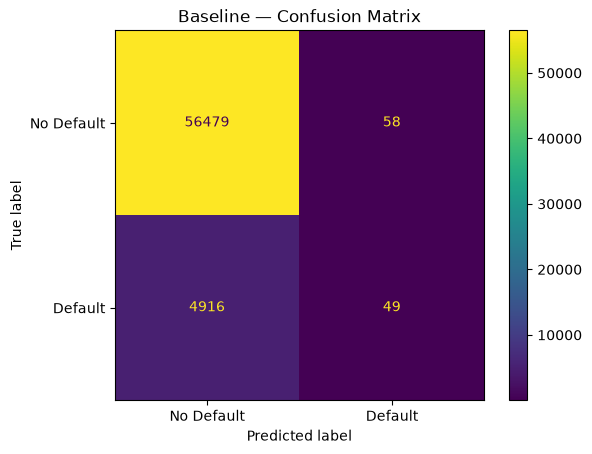

In [22]:
# ------------------------------------------------------------------
#  Baseline Logistic Regression (no imbalance handling)
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

lr_baseline = LogisticRegression(max_iter=1000, random_state=912)
lr_baseline.fit(X_train_scaled, y_train)

y_pred_baseline    = lr_baseline.predict(X_test_scaled)
y_proba_baseline   = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("=== Baseline Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Baseline — Confusion Matrix")
plt.show()

**LOGISTIC REGRESSION (CLASS WEIGHTING)**

=== Class Weighted Logistic Regression ===
ROC-AUC: 0.7459
              precision    recall  f1-score   support

  No Default       0.96      0.68      0.80     56537
     Default       0.16      0.68      0.26      4965

    accuracy                           0.68     61502
   macro avg       0.56      0.68      0.53     61502
weighted avg       0.90      0.68      0.75     61502



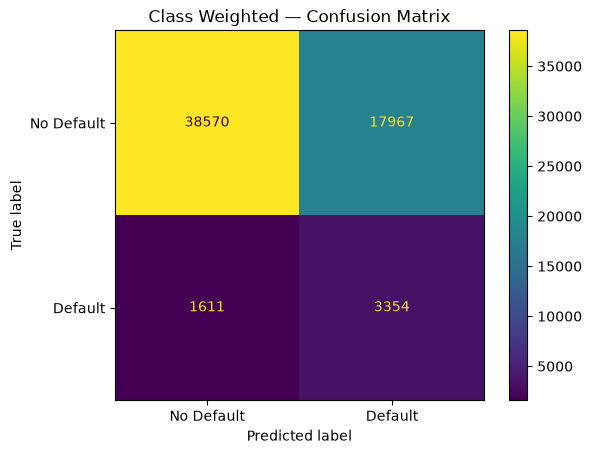

In [23]:
# ------------------------------------------------------------------
#  Class Weighted Logistic Regression
# ------------------------------------------------------------------
lr_weighted = LogisticRegression(max_iter=1000, random_state=912, class_weight={0: 0.08, 1: 0.92})
lr_weighted.fit(X_train_scaled, y_train)

y_pred_weighted  = lr_weighted.predict(X_test_scaled)
y_proba_weighted = lr_weighted.predict_proba(X_test_scaled)[:, 1]

print("=== Class Weighted Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_weighted):.4f}")
print(classification_report(y_test, y_pred_weighted, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_weighted)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Class Weighted — Confusion Matrix")
plt.show()

**LOGISTIC REGRESSION (SMOTE)**

After SMOTE — Train shape: (452290, 64)
Class distribution: {0: 226145, 1: 226145}

=== SMOTE Logistic Regression ===
ROC-AUC: 0.7416
              precision    recall  f1-score   support

  No Default       0.96      0.69      0.80     56537
     Default       0.16      0.66      0.26      4965

    accuracy                           0.69     61502
   macro avg       0.56      0.68      0.53     61502
weighted avg       0.89      0.69      0.76     61502



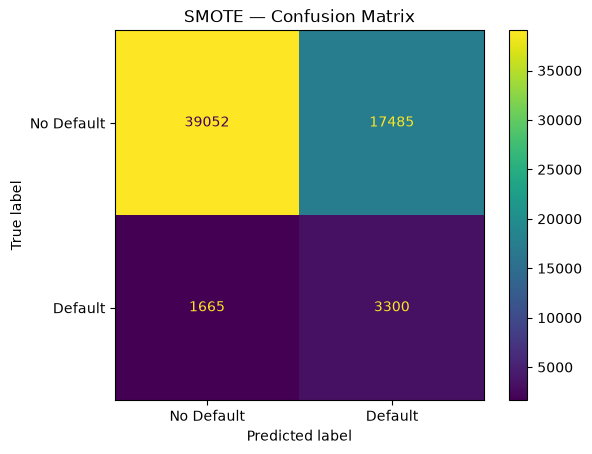

In [24]:
# ------------------------------------------------------------------
#  SMOTE + Logistic Regression
# ------------------------------------------------------------------
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=912)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE — Train shape: {X_train_smote.shape}")
print(f"Class distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote  = lr_smote.predict(X_test_scaled)
y_proba_smote = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("\n=== SMOTE Logistic Regression ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_smote):.4f}")
print(classification_report(y_test, y_pred_smote, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_smote)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("SMOTE — Confusion Matrix")
plt.show()

**DECISION TREE**

=== Full Decision Tree (unpruned) ===
Tree depth: 68
Number of leaves: 24460
ROC-AUC: 0.5375
              precision    recall  f1-score   support

  No Default       0.93      0.92      0.92     56537
     Default       0.15      0.15      0.15      4965

    accuracy                           0.86     61502
   macro avg       0.54      0.54      0.54     61502
weighted avg       0.86      0.86      0.86     61502



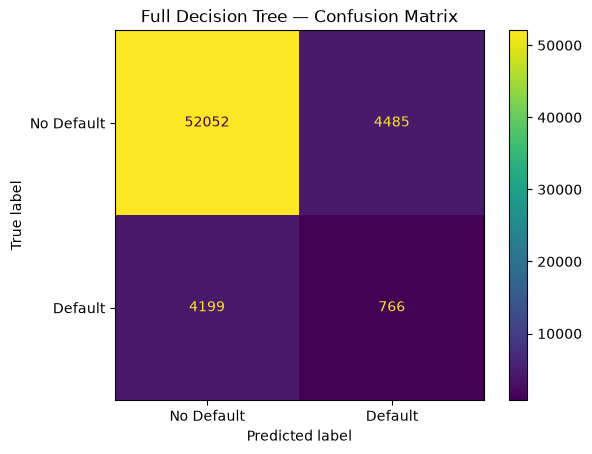

In [25]:
# ------------------------------------------------------------------
#  Full Decision Tree (unpruned)
# ------------------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier

dt_full = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=912
)
dt_full.fit(X_train_scaled, y_train)

y_pred_dt_full  = dt_full.predict(X_test_scaled)
y_proba_dt_full = dt_full.predict_proba(X_test_scaled)[:, 1]

print("=== Full Decision Tree (unpruned) ===")
print(f"Tree depth: {dt_full.get_depth()}")
print(f"Number of leaves: {dt_full.get_n_leaves()}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_dt_full):.4f}")
print(classification_report(y_test, y_pred_dt_full, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_dt_full)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Full Decision Tree — Confusion Matrix")
plt.show()

In [26]:
# ------------------------------------------------------------------
#  Check train performance (overfit check)
# ------------------------------------------------------------------
y_pred_dt_train  = dt_full.predict(X_train_scaled)
y_proba_dt_train = dt_full.predict_proba(X_train_scaled)[:, 1]

print("=== Full Decision Tree — TRAIN performance ===")
print(f"ROC-AUC (train): {roc_auc_score(y_train, y_proba_dt_train):.4f}")
print(classification_report(y_train, y_pred_dt_train, target_names=["No Default", "Default"]))

=== Full Decision Tree — TRAIN performance ===
ROC-AUC (train): 1.0000
              precision    recall  f1-score   support

  No Default       1.00      1.00      1.00    226145
     Default       1.00      1.00      1.00     19860

    accuracy                           1.00    246005
   macro avg       1.00      1.00      1.00    246005
weighted avg       1.00      1.00      1.00    246005



**DECISION TREE (PRUNED)**

 max_depth  AUC_train  AUC_test  overfit_gap
         3     0.6891    0.6864       0.0026
         5     0.7151    0.7084       0.0066
         7     0.7360    0.7128       0.0232
        10     0.7810    0.6943       0.0867
        15     0.8895    0.6350       0.2545
        20     0.9543    0.6000       0.3543


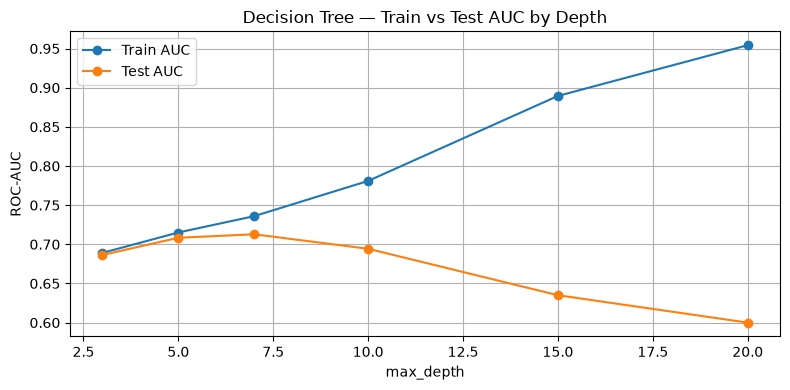

In [27]:
# ------------------------------------------------------------------
# Pruned Decision Trees (try multiple depths)
# ------------------------------------------------------------------
depths = [3, 5, 7, 10, 15, 20]
results = []

for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=912
    )
    dt.fit(X_train_scaled, y_train)

    y_proba_train = dt.predict_proba(X_train_scaled)[:, 1]
    y_proba_test  = dt.predict_proba(X_test_scaled)[:, 1]

    auc_train = roc_auc_score(y_train, y_proba_train)
    auc_test  = roc_auc_score(y_test,  y_proba_test)

    results.append({
        "max_depth"  : depth,
        "AUC_train"  : round(auc_train, 4),
        "AUC_test"   : round(auc_test,  4),
        "overfit_gap": round(auc_train - auc_test, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot train vs test AUC across depths
plt.figure(figsize=(8, 4))
plt.plot(results_df["max_depth"], results_df["AUC_train"], marker="o", label="Train AUC")
plt.plot(results_df["max_depth"], results_df["AUC_test"],  marker="o", label="Test AUC")
plt.xlabel("max_depth")
plt.ylabel("ROC-AUC")
plt.title("Decision Tree — Train vs Test AUC by Depth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "dt_depth_auc.png", dpi=150)
plt.show()

**RANDOM FOREST**

=== Random Forest ===
ROC-AUC: 0.7470
              precision    recall  f1-score   support

  No Default       0.92      0.99      0.96     56537
     Default       0.42      0.06      0.11      4965

    accuracy                           0.92     61502
   macro avg       0.67      0.53      0.53     61502
weighted avg       0.88      0.92      0.89     61502



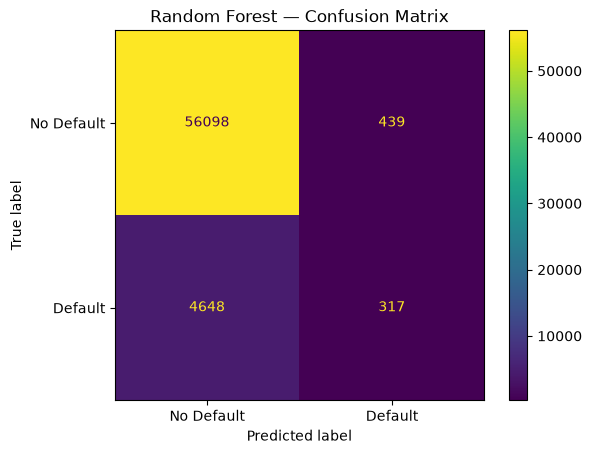

In [28]:
# ------------------------------------------------------------------
#  Random Forest baseline
# ------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=912,
    n_jobs=-1        # use all CPU cores
)
rf.fit(X_train_scaled, y_train)

y_pred_rf  = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Random Forest — Confusion Matrix")
plt.show()

In [29]:
# ------------------------------------------------------------------
# Overfit check (train vs test)
# ------------------------------------------------------------------
y_proba_rf_train = rf.predict_proba(X_train_scaled)[:, 1]

print(f"ROC-AUC Train: {roc_auc_score(y_train, y_proba_rf_train):.4f}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test,  y_proba_rf):.4f}")
print(f"Overfit gap:   {roc_auc_score(y_train, y_proba_rf_train) - roc_auc_score(y_test, y_proba_rf):.4f}")

ROC-AUC Train: 1.0000
ROC-AUC Test:  0.7470
Overfit gap:   0.2530


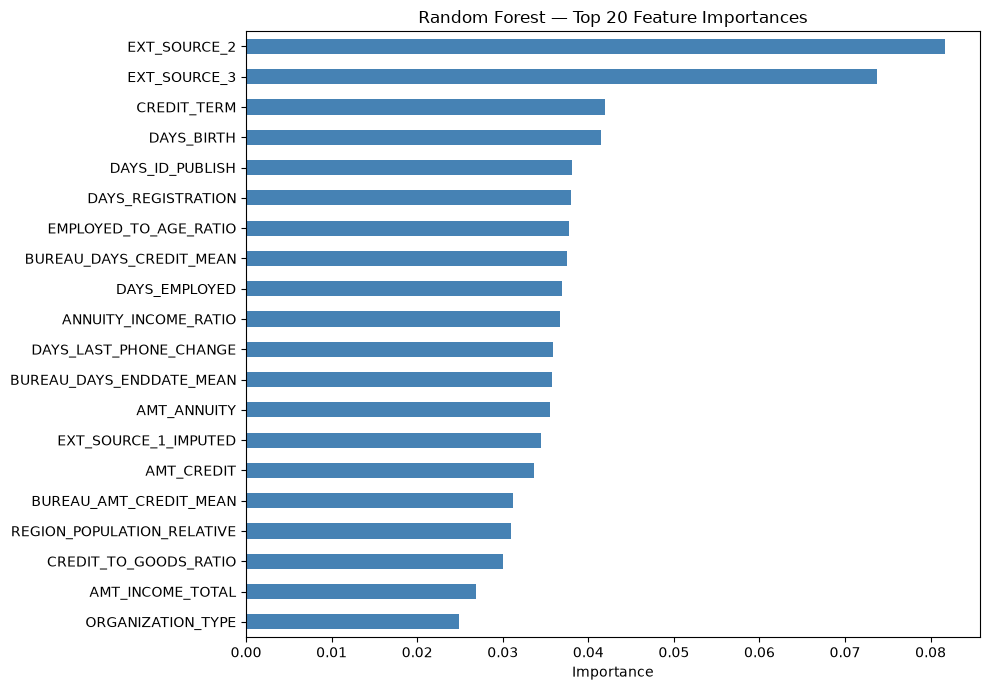

EXT_SOURCE_2                  0.081689
EXT_SOURCE_3                  0.073745
CREDIT_TERM                   0.041892
DAYS_BIRTH                    0.041429
DAYS_ID_PUBLISH               0.038075
DAYS_REGISTRATION             0.037920
EMPLOYED_TO_AGE_RATIO         0.037696
BUREAU_DAYS_CREDIT_MEAN       0.037525
DAYS_EMPLOYED                 0.036966
ANNUITY_INCOME_RATIO          0.036670
DAYS_LAST_PHONE_CHANGE        0.035869
BUREAU_DAYS_ENDDATE_MEAN      0.035780
AMT_ANNUITY                   0.035575
EXT_SOURCE_1_IMPUTED          0.034420
AMT_CREDIT                    0.033645
BUREAU_AMT_CREDIT_MEAN        0.031226
REGION_POPULATION_RELATIVE    0.030985
CREDIT_TO_GOODS_RATIO         0.030054
AMT_INCOME_TOTAL              0.026897
ORGANIZATION_TYPE             0.024933


In [30]:
# ------------------------------------------------------------------
# Feature importance (top 20)
# ------------------------------------------------------------------
importances = pd.Series(rf.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Random Forest — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "rf_feature_importance.png", dpi=150)
plt.show()

print(importances.to_string())

=== Constrained Random Forest ===
ROC-AUC Train: 0.7891
ROC-AUC Test:  0.7453
Overfit gap:   0.0438
              precision    recall  f1-score   support

  No Default       0.96      0.70      0.81     56537
     Default       0.16      0.66      0.26      4965

    accuracy                           0.70     61502
   macro avg       0.56      0.68      0.54     61502
weighted avg       0.90      0.70      0.77     61502



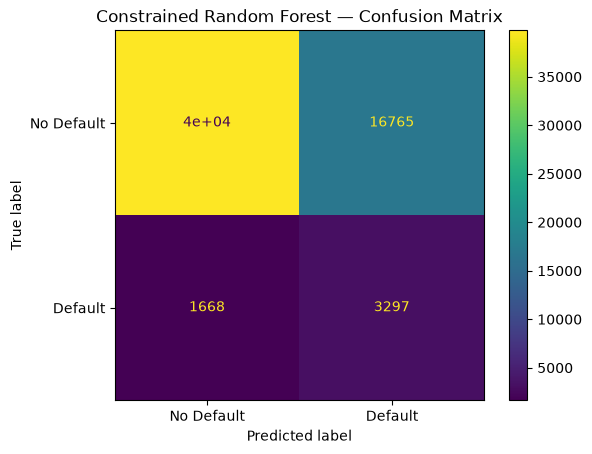

In [31]:
# ------------------------------------------------------------------
#  Constrained Random Forest
# ------------------------------------------------------------------
rf_constrained = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=100,    # each leaf must have at least 50 samples
    class_weight="balanced",
    random_state= 912,
    n_jobs=-1
)
rf_constrained.fit(X_train_scaled, y_train)

y_pred_rfc  = rf_constrained.predict(X_test_scaled)
y_proba_rfc = rf_constrained.predict_proba(X_test_scaled)[:, 1]

y_proba_rfc_train = rf_constrained.predict_proba(X_train_scaled)[:, 1]

print("=== Constrained Random Forest ===")
print(f"ROC-AUC Train: {roc_auc_score(y_train, y_proba_rfc_train):.4f}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test,  y_proba_rfc):.4f}")
print(f"Overfit gap:   {roc_auc_score(y_train, y_proba_rfc_train) - roc_auc_score(y_test, y_proba_rfc):.4f}")
print(classification_report(y_test, y_pred_rfc, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_rfc)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("Constrained Random Forest — Confusion Matrix")
plt.show()

**GRADIENT BOOSTED MODELS**

**XGBOOST**

scale_pos_weight: 11.39
[0]	validation_0-auc:0.70294
[50]	validation_0-auc:0.73797
[100]	validation_0-auc:0.74944
[150]	validation_0-auc:0.75498
[200]	validation_0-auc:0.75798
[250]	validation_0-auc:0.75962
[300]	validation_0-auc:0.76068
[350]	validation_0-auc:0.76118
[400]	validation_0-auc:0.76179
[450]	validation_0-auc:0.76286
[500]	validation_0-auc:0.76353
[550]	validation_0-auc:0.76377
[600]	validation_0-auc:0.76418
[650]	validation_0-auc:0.76445
[700]	validation_0-auc:0.76484
[750]	validation_0-auc:0.76495
[799]	validation_0-auc:0.76502

=== XGBoost ===
Best iteration: 796
ROC-AUC Test:  0.7650
              precision    recall  f1-score   support

  No Default       0.96      0.72      0.82     56537
     Default       0.17      0.67      0.28      4965

    accuracy                           0.72     61502
   macro avg       0.57      0.70      0.55     61502
weighted avg       0.90      0.72      0.78     61502



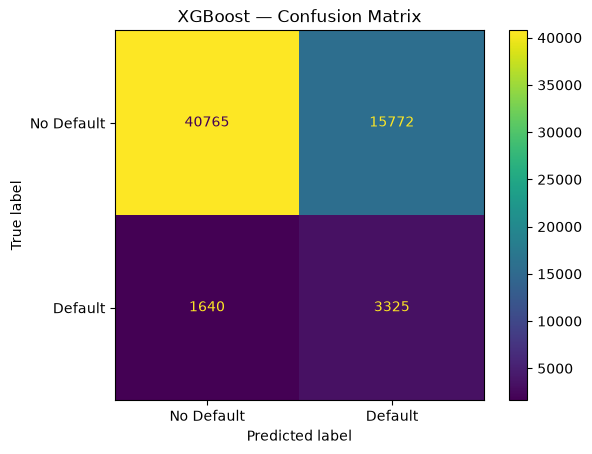

In [32]:
# ------------------------------------------------------------------
#  XGBoost baseline
# ------------------------------------------------------------------
from xgboost import XGBClassifier

# scale_pos_weight handles imbalance — ratio of negative to positive samples
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=800,
    learning_rate=0.04,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    random_state=912,
    n_jobs=-1,
    eval_metric="auc",
    early_stopping_rounds=30,  # stop if no improvement for 50 rounds
)

xgb.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=50   # print AUC every 50 trees
)

y_pred_xgb  = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("\n=== XGBoost ===")
print(f"Best iteration: {xgb.best_iteration}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("XGBoost — Confusion Matrix")
plt.show()

In [33]:
# ------------------------------------------------------------------
# Overfit check
# ------------------------------------------------------------------
y_proba_xgb_train = xgb.predict_proba(X_train_scaled)[:, 1]

print(f"ROC-AUC Train: {roc_auc_score(y_train, y_proba_xgb_train):.4f}")
print(f"ROC-AUC Test:  {roc_auc_score(y_test,  y_proba_xgb):.4f}")
print(f"Overfit gap:   {roc_auc_score(y_train, y_proba_xgb_train) - roc_auc_score(y_test, y_proba_xgb):.4f}")

ROC-AUC Train: 0.8080
ROC-AUC Test:  0.7650
Overfit gap:   0.0430


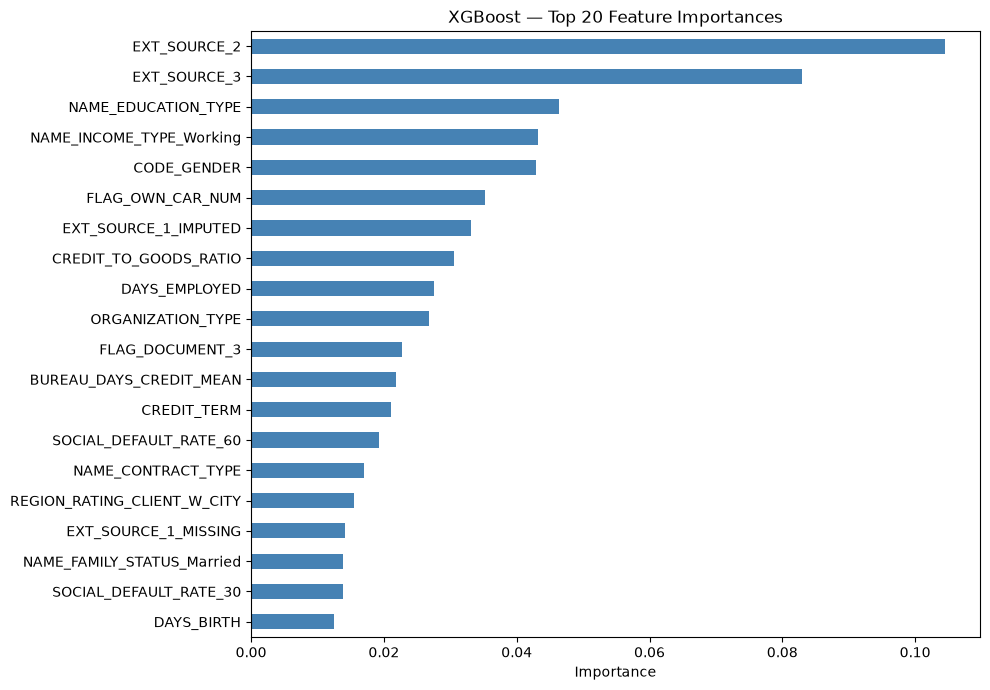

EXT_SOURCE_2                   0.104542
EXT_SOURCE_3                   0.082966
NAME_EDUCATION_TYPE            0.046435
NAME_INCOME_TYPE_Working       0.043188
CODE_GENDER                    0.042944
FLAG_OWN_CAR_NUM               0.035238
EXT_SOURCE_1_IMPUTED           0.033058
CREDIT_TO_GOODS_RATIO          0.030507
DAYS_EMPLOYED                  0.027581
ORGANIZATION_TYPE              0.026758
FLAG_DOCUMENT_3                0.022798
BUREAU_DAYS_CREDIT_MEAN        0.021770
CREDIT_TERM                    0.021017
SOCIAL_DEFAULT_RATE_60         0.019235
NAME_CONTRACT_TYPE             0.016953
REGION_RATING_CLIENT_W_CITY    0.015499
EXT_SOURCE_1_MISSING           0.014210
NAME_FAMILY_STATUS_Married     0.013901
SOCIAL_DEFAULT_RATE_30         0.013783
DAYS_BIRTH                     0.012416


In [34]:
# ------------------------------------------------------------------
#  Feature importance
# ------------------------------------------------------------------
importances = pd.Series(xgb.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("XGBoost — Top 20 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "xgb_feature_importance.png", dpi=150)
plt.show()

print(importances.to_string())

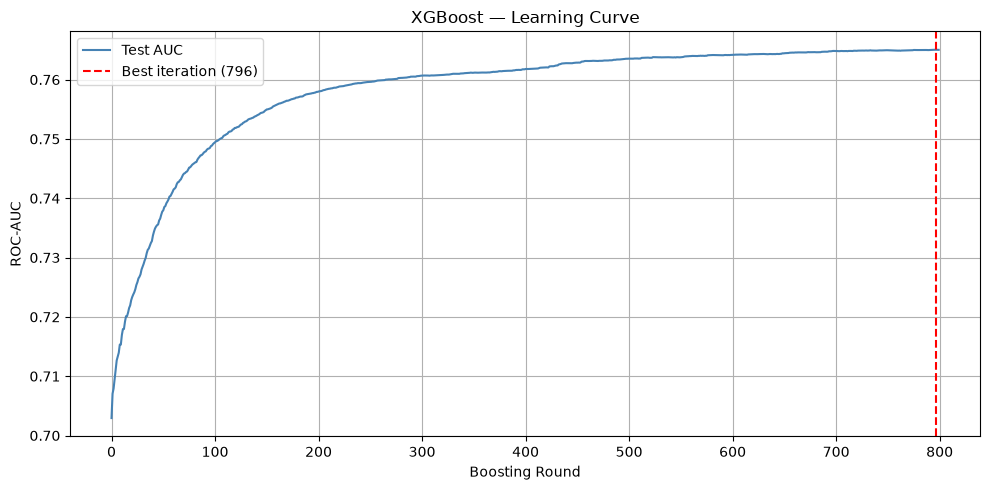

In [35]:
# ------------------------------------------------------------------
# Learning curve (train vs test AUC over boosting rounds)
# ------------------------------------------------------------------
results = xgb.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["auc"], label="Test AUC", color="steelblue")
plt.axvline(xgb.best_iteration, color="red", linestyle="--", label=f"Best iteration ({xgb.best_iteration})")
plt.xlabel("Boosting Round")
plt.ylabel("ROC-AUC")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "xgb_learning_curve.png", dpi=150)
plt.show()

**LIGHTGBM**

In [36]:
# ------------------------------------------------------------------
# LightGBM baseline
# ------------------------------------------------------------------
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")
# ------------------------------------------------------------------
# LightGBM — fixed
# ------------------------------------------------------------------
lgbm = LGBMClassifier(
    n_estimators=10000,
    learning_rate=0.01,       # reduced from 0.05. slower, more stable
    max_depth=4,
    num_leaves=20,            # reduced from 31 — less complex trees
    min_child_samples=100,    # minimum samples per leaf — prevents overfitting
    subsample=0.8,            # use 80% of rows per tree (like Random Forest)
    colsample_bytree=0.8,     # use 80% of features per tree
    reg_alpha=0.1,            # L1 regularization
    reg_lambda=0.1,           # L2 regularization
    scale_pos_weight=1.25,
    random_state=912,
    n_jobs=-1,
    verbose=-1,               # suppress warnings
)

lgbm.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    eval_metric="auc",
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=True),
        log_evaluation(period=50)
    ]
)

y_pred_lgbm  = lgbm.predict(X_test_scaled)
y_proba_lgbm = lgbm.predict_proba(X_test_scaled)[:, 1]

print(f"\nBest iteration: {lgbm.best_iteration_}")
print(f"\n=== LightGBM (fixed) ===")
print(f"ROC-AUC Test: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(classification_report(y_test, y_pred_lgbm, target_names=["No Default", "Default"]))

print(f"\nProbability distribution:")
print(pd.Series(y_proba_lgbm).describe())


scale_pos_weight: 11.39


d:\Ahmed\Credit_Loan_Risk\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.726436	valid_0's binary_logloss: 0.265988
[100]	valid_0's auc: 0.732345	valid_0's binary_logloss: 0.260161
[150]	valid_0's auc: 0.73613	valid_0's binary_logloss: 0.257081
[200]	valid_0's auc: 0.739695	valid_0's binary_logloss: 0.255152
[250]	valid_0's auc: 0.743397	valid_0's binary_logloss: 0.253665
[300]	valid_0's auc: 0.746576	valid_0's binary_logloss: 0.252511
[350]	valid_0's auc: 0.748846	valid_0's binary_logloss: 0.251624
[400]	valid_0's auc: 0.750895	valid_0's binary_logloss: 0.250853
[450]	valid_0's auc: 0.752588	valid_0's binary_logloss: 0.250215
[500]	valid_0's auc: 0.753999	valid_0's binary_logloss: 0.249656
[550]	valid_0's auc: 0.755453	valid_0's binary_logloss: 0.24913
[600]	valid_0's auc: 0.756602	valid_0's binary_logloss: 0.248705
[650]	valid_0's auc: 0.75764	valid_0's binary_logloss: 0.248327
[700]	valid_0's auc: 0.75849	valid_0's binary_logloss: 0.248003
[750]	valid_0's auc: 0.759199	vali

 threshold  default_precision  default_recall  default_f1  accuracy
      0.05              0.121           0.887       0.212     0.468
      0.06              0.132           0.850       0.228     0.537
      0.07              0.143           0.807       0.243     0.593
      0.08              0.152           0.761       0.254     0.638
      0.09              0.162           0.723       0.265     0.676
      0.10              0.172           0.685       0.276     0.709
      0.11              0.181           0.647       0.283     0.736
      0.12              0.192           0.613       0.292     0.760
      0.13              0.201           0.578       0.298     0.780
      0.14              0.211           0.548       0.305     0.798
      0.15              0.222           0.521       0.311     0.814
      0.16              0.232           0.494       0.315     0.827
      0.17              0.241           0.466       0.317     0.838
      0.18              0.250           0.440   

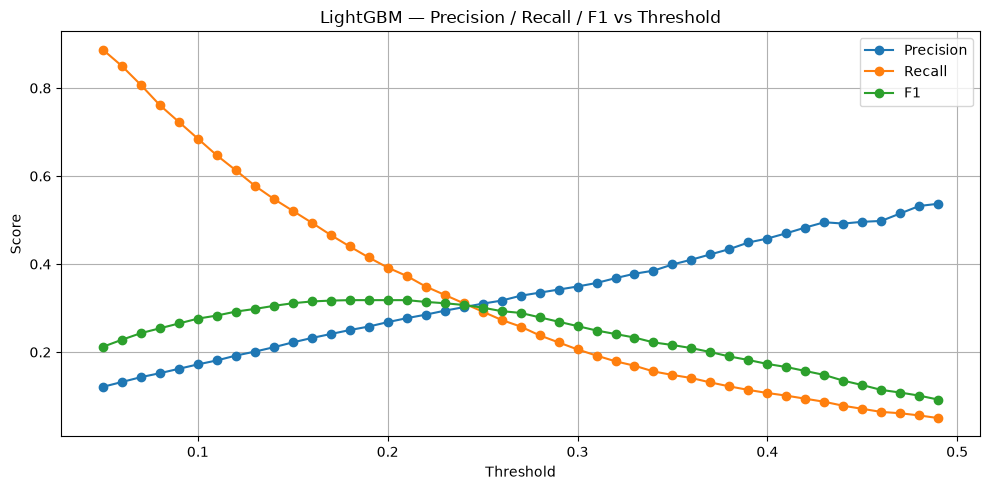

In [37]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

# ------------------------------------------------------------------
# Threshold tuning — find optimal cutoff
# ------------------------------------------------------------------
thresholds = np.arange(0.05, 0.50, 0.01)
results = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_lgbm >= thresh).astype(int)
    report = classification_report(y_test, y_pred_thresh,
                                   target_names=["No Default", "Default"],
                                   output_dict=True)
    results.append({
        "threshold"        : round(thresh, 2),
        "default_precision": round(report["Default"]["precision"], 3),
        "default_recall"   : round(report["Default"]["recall"], 3),
        "default_f1"       : round(report["Default"]["f1-score"], 3),
        "accuracy"         : round(report["accuracy"], 3),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot precision/recall tradeoff
plt.figure(figsize=(10, 5))
plt.plot(results_df["threshold"], results_df["default_precision"], label="Precision", marker="o")
plt.plot(results_df["threshold"], results_df["default_recall"],    label="Recall",    marker="o")
plt.plot(results_df["threshold"], results_df["default_f1"],        label="F1",        marker="o")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("LightGBM — Precision / Recall / F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "lgbm_threshold_tuning.png", dpi=150)
plt.show()

=== LightGBM at threshold 0.1 ===
ROC-AUC: 0.7678
              precision    recall  f1-score   support

  No Default       0.96      0.71      0.82     56537
     Default       0.17      0.69      0.28      4965

    accuracy                           0.71     61502
   macro avg       0.57      0.70      0.55     61502
weighted avg       0.90      0.71      0.77     61502



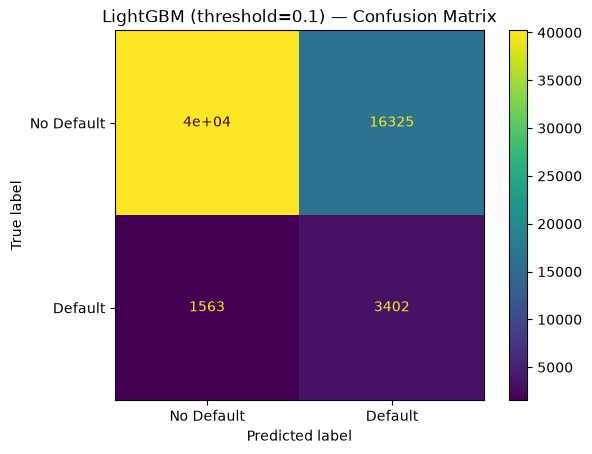

In [38]:
# ------------------------------------------------------------------
# Apply chosen threshold
# ------------------------------------------------------------------
best_threshold = 0.1

y_pred_final = (y_proba_lgbm >= best_threshold).astype(int)

print(f"=== LightGBM at threshold {best_threshold} ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
print(classification_report(y_test, y_pred_final, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title(f"LightGBM (threshold={best_threshold}) — Confusion Matrix")
plt.show()

**___________________________________________________________________________________**

**SAVING MODEL**

In [48]:

import os
import joblib          # works for both sklearn‑style and native LightGBM boosters
import lightgbm as lgb

model_dir = r"d://Ahmed//Credit_Loan_Risk//models"
os.makedirs(model_dir, exist_ok=True)


model_path_pkl = os.path.join(model_dir, "lgbm_model.pkl")
joblib.dump(lgbm, model_path_pkl)       # fast, preserves the full Python object


['d://Ahmed//Credit_Loan_Risk//models\\lgbm_model.pkl']

**RANDOM SEARCH FOR LIGHTGBM**

In [39]:
# ------------------------------------------------------------------
# Cell 1 — Define parameter space
# ------------------------------------------------------------------
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators"      : randint(200, 1000),
    "learning_rate"     : uniform(0.01, 0.09),      # 0.01 to 0.10
    "max_depth"         : randint(3, 10),
    "num_leaves"        : randint(15, 63),
    "min_child_samples" : randint(20, 200),
    "subsample"         : uniform(0.6, 0.4),         # 0.6 to 1.0
    "colsample_bytree"  : uniform(0.6, 0.4),         # 0.6 to 1.0
    "reg_alpha"         : uniform(0, 0.5),           # L1
    "reg_lambda"        : uniform(0, 0.5),           # L2
    "scale_pos_weight"  : [1, 1.25, 1.5, 2,  3, 5],         # imbalance handling options
}



In [40]:
# ------------------------------------------------------------------
# Cell 2 — Run RandomizedSearchCV
# ------------------------------------------------------------------
from sklearn.model_selection import StratifiedKFold

lgbm_base = LGBMClassifier(
    random_state=912,
    n_jobs=-1,
    verbose=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=50,              # try 50 random combinations
    scoring="roc_auc",      # optimize for ROC-AUC
    cv=cv,                  # 5-fold stratified cross validation
    random_state=912,
    n_jobs=-1,
    verbose=2,              # print progress
    refit=True,             # refit best model on full train set
)

search.fit(X_train_scaled, y_train)

print(f"\nBest ROC-AUC (CV): {search.best_score_:.4f}")
print(f"\nBest parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best ROC-AUC (CV): 0.7715

Best parameters:
  colsample_bytree: 0.6232237590659276
  learning_rate: 0.04606137655490713
  max_depth: 5
  min_child_samples: 153
  n_estimators: 777
  num_leaves: 26
  reg_alpha: 0.39256346734534553
  reg_lambda: 0.08568224234177496
  scale_pos_weight: 5
  subsample: 0.9910565472584264


=== LightGBM (tuned) ===
ROC-AUC Test: 0.7675
              precision    recall  f1-score   support

  No Default       0.96      0.70      0.81     56537
     Default       0.17      0.69      0.27      4965

    accuracy                           0.70     61502
   macro avg       0.57      0.70      0.54     61502
weighted avg       0.90      0.70      0.77     61502



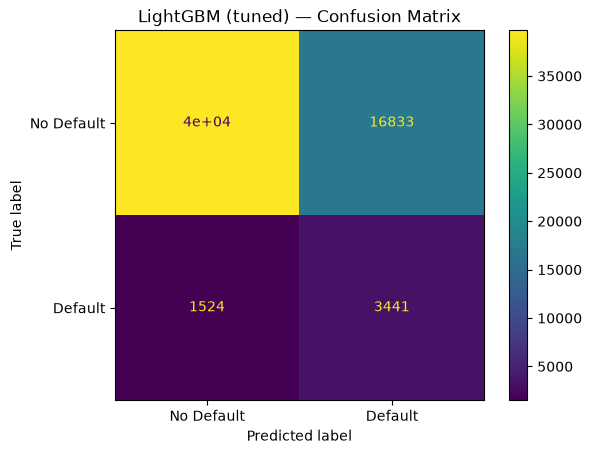


Probability distribution:
count    61502.000000
mean         0.248207
std          0.179964
min          0.001313
25%          0.107629
50%          0.198548
75%          0.347907
max          0.920650
dtype: float64


In [47]:
# ------------------------------------------------------------------
# Cell 3 — Evaluate best model on test set
# ------------------------------------------------------------------
best_lgbm = search.best_estimator_

y_proba_best = best_lgbm.predict_proba(X_test_scaled)[:, 1]
y_pred_best  = (y_proba_best >= 0.29).astype(int)  # use same threshold as before

print("=== LightGBM (tuned) ===")
print(f"ROC-AUC Test: {roc_auc_score(y_test, y_proba_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title("LightGBM (tuned) — Confusion Matrix")
plt.show()

# Probability distribution
print("\nProbability distribution:")
print(pd.Series(y_proba_best).describe())

Top 10 parameter combinations:
 mean_test_score  std_test_score  param_colsample_bytree  param_learning_rate  param_max_depth  param_min_child_samples  param_n_estimators  param_num_leaves  param_reg_alpha  param_reg_lambda  param_scale_pos_weight  param_subsample
        0.771544        0.003684                0.623224             0.046061                5                      153                 777                26         0.392563          0.085682                    5.00         0.991057
        0.771298        0.004078                0.789870             0.034989                5                       82                 843                26         0.286552          0.136034                    5.00         0.880977
        0.771122        0.003882                0.630327             0.017055                9                       70                 981                40         0.275923          0.085203                    5.00         0.866626
        0.771104        0.003745 

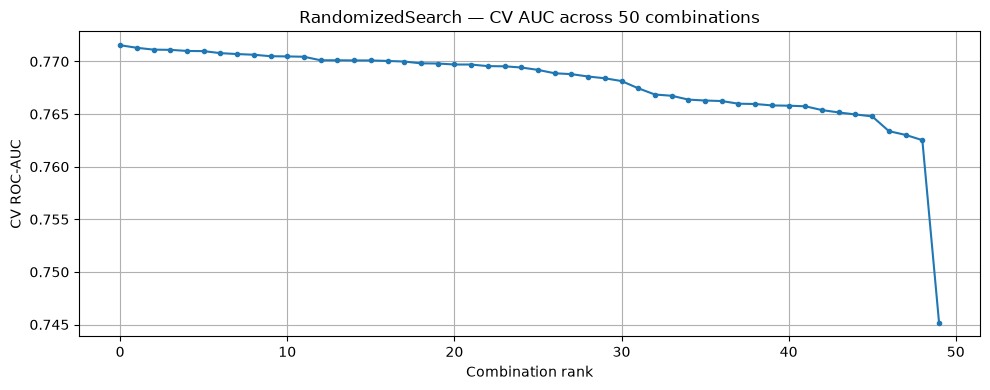

In [42]:
# ------------------------------------------------------------------
# Cell 4 — Compare CV results across all 50 runs
# ------------------------------------------------------------------
cv_results = pd.DataFrame(search.cv_results_)
cv_results = cv_results.sort_values("mean_test_score", ascending=False)

print("Top 10 parameter combinations:")
cols = ["mean_test_score", "std_test_score"] + [
    c for c in cv_results.columns if c.startswith("param_")
]
print(cv_results[cols].head(10).to_string(index=False))

# Plot distribution of CV scores across all 50 runs
plt.figure(figsize=(10, 4))
plt.plot(cv_results["mean_test_score"].values, marker="o", markersize=3)
plt.xlabel("Combination rank")
plt.ylabel("CV ROC-AUC")
plt.title("RandomizedSearch — CV AUC across 50 combinations")
plt.grid(True)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "reports" / "figures" / "lgbm_gridsearch.png", dpi=150)
plt.show()

**KNN**

In [43]:
# ------------------------------------------------------------------
# Cell 1 — KNN
# ------------------------------------------------------------------
from sklearn.neighbors import KNeighborsClassifier

# Try a few values of K
k_values = [ 15, 25, 35, 55]
results = []

for k in k_values:
    print(f"Fitting KNN with k={k}...")
    knn = KNeighborsClassifier(
        n_neighbors=k,
        algorithm="ball_tree",  # most efficient for this size
        n_jobs=-1
    )
    knn.fit(X_train_scaled, y_train)

    y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba_knn)
    print(f"  k={k}: ROC-AUC = {auc:.4f}")

    results.append({"k": k, "ROC-AUC": round(auc, 4)})

results_df = pd.DataFrame(results)
print("\n=== KNN Results ===")
print(results_df.to_string(index=False))

Fitting KNN with k=15...
  k=15: ROC-AUC = 0.6555
Fitting KNN with k=25...
  k=25: ROC-AUC = 0.6793
Fitting KNN with k=35...
  k=35: ROC-AUC = 0.6913
Fitting KNN with k=55...
  k=55: ROC-AUC = 0.7027

=== KNN Results ===
 k  ROC-AUC
15   0.6555
25   0.6793
35   0.6913
55   0.7027


Best k: 55

=== KNN (k=55) ===
ROC-AUC: 0.7027
              precision    recall  f1-score   support

  No Default       0.95      0.75      0.84     56537
     Default       0.16      0.55      0.25      4965

    accuracy                           0.73     61502
   macro avg       0.56      0.65      0.54     61502
weighted avg       0.89      0.73      0.79     61502



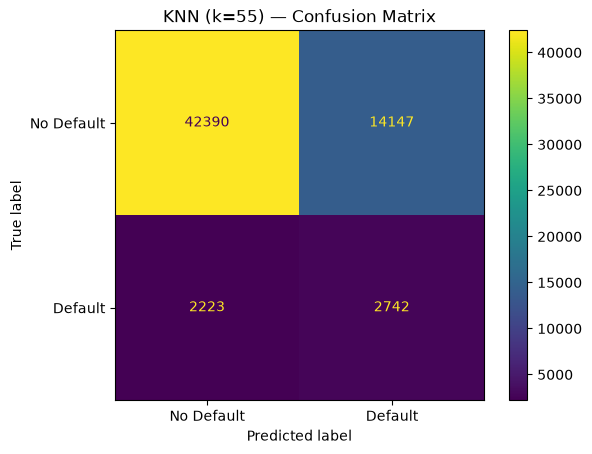


Probability distribution:
count    61502.000000
mean         0.076408
std          0.063458
min          0.000000
25%          0.036364
50%          0.054545
75%          0.109091
max          0.563636
dtype: float64


In [44]:
# ------------------------------------------------------------------
# Cell 2 — Best K full evaluation
# ------------------------------------------------------------------
best_k = results_df.loc[results_df["ROC-AUC"].idxmax(), "k"]
print(f"Best k: {best_k}")

knn_best = KNeighborsClassifier(
    n_neighbors=best_k,
    algorithm="ball_tree",
    n_jobs=-1
)
knn_best.fit(X_train_scaled, y_train)

y_proba_knn_best = knn_best.predict_proba(X_test_scaled)[:, 1]
y_pred_knn_best  = (y_proba_knn_best >= 0.10).astype(int)

print(f"\n=== KNN (k={best_k}) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_knn_best):.4f}")
print(classification_report(y_test, y_pred_knn_best, target_names=["No Default", "Default"]))

cm = confusion_matrix(y_test, y_pred_knn_best)
ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"]).plot()
plt.title(f"KNN (k={best_k}) — Confusion Matrix")
plt.show()

print("\nProbability distribution:")
print(pd.Series(y_proba_knn_best).describe())